In [ ]:
# Cell 1:Environment & Label (Menggabungkan import library, mounting Drive, dan penentuan jalur folder dataset.)
import os
import time
import itertools
import torch
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from google.colab import drive

# Mounting Drive
drive.mount('/content/drive')

# Tentukan Path (Pastikan folder trainA/B sudah berisi 100 foto)
PROJECT_FOLDER = 'CycleGAN_Project'
DATASET_PATH = f'/content/drive/MyDrive/{PROJECT_FOLDER}/dataset'

# Cek GPU (Wajib muncul "cuda")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Sistem berjalan di: {device}")
if device.type != 'cuda':
    print("PERINGATAN: GPU belum aktif! Hasil akan jelek dan lambat.")

Mounted at /content/drive
Sistem berjalan di: cuda


In [ ]:
# Cell 2: Architecture Definnition (Menggabungkan definisi ResnetBlock, ResnetGenerator, dan NLayerDiscriminator (PatchGAN) dalam satu urutan arsitektur.)
# --- Blok ResNet ---
class ResnetBlock(nn.Module):
    def __init__(self, dim):
        super(ResnetBlock, self).__init__()
        self.conv_block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, kernel_size=3, padding=0, bias=False),
            nn.InstanceNorm2d(dim),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, kernel_size=3, padding=0, bias=False),
            nn.InstanceNorm2d(dim)
        )
    def forward(self, x): return x + self.conv_block(x)

# --- Generator (Perbaikan Upsampling) ---
class ResnetGenerator(nn.Module):
    def __init__(self, input_nc, output_nc, ngf=64, n_blocks=6): # n_blocks=6 untuk stabilitas
        super(ResnetGenerator, self).__init__()
        # Encoder
        model = [nn.ReflectionPad2d(3), nn.Conv2d(input_nc, ngf, 7, padding=0, bias=False), nn.InstanceNorm2d(ngf), nn.ReLU(True)]
        for i in range(2):
            mult = 2**i
            model += [nn.Conv2d(ngf*mult, ngf*mult*2, 3, stride=2, padding=1, bias=False), nn.InstanceNorm2d(ngf*mult*2), nn.ReLU(True)]

        # Bottleneck
        mult = 2**2
        for i in range(n_blocks): model += [ResnetBlock(ngf*mult)]

        # Decoder (PERBAIKAN: Ganti ConvTranspose dengan Upsample + Conv)
        for i in range(2):
            mult = 2**(2-i)
            model += [
                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                nn.Conv2d(ngf*mult, int(ngf*mult/2), kernel_size=3, stride=1, padding=1, bias=False),
                nn.InstanceNorm2d(int(ngf*mult/2)),
                nn.ReLU(True)
            ]

        model += [nn.ReflectionPad2d(3), nn.Conv2d(ngf, output_nc, 7, padding=0), nn.Tanh()]
        self.model = nn.Sequential(*model)

    def forward(self, x): return self.model(x)

# --- Discriminator PatchGAN ---
class NLayerDiscriminator(nn.Module):
    def __init__(self, input_nc, ndf=64, n_layers=3):
        super(NLayerDiscriminator, self).__init__()
        model = [nn.Conv2d(input_nc, ndf, kernel_size=4, stride=2, padding=1), nn.LeakyReLU(0.2, True)]
        nf_mult = 1
        for n in range(1, n_layers):
            nf_mult_prev = nf_mult
            nf_mult = min(2**n, 8)
            model += [nn.Conv2d(ndf*nf_mult_prev, ndf*nf_mult, 4, stride=2, padding=1, bias=False), nn.InstanceNorm2d(ndf*nf_mult), nn.LeakyReLU(0.2, True)]
        model += [nn.Conv2d(ndf*nf_mult, 1, kernel_size=4, stride=1, padding=1)]
        self.model = nn.Sequential(*model)

    def forward(self, x): return self.model(x)

In [ ]:
# Cell 3: Data Pipeline (Menggabungkan kelas CycleGANDataset dengan definisi transform (augmentasi) dan inisialisasi dataloader.)
class CycleGANDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_A = os.path.join(root_dir, 'trainA')
        self.root_B = os.path.join(root_dir, 'trainB')
        self.files_A = [f for f in os.listdir(self.root_A) if f.endswith(('.jpg', '.png'))]
        self.files_B = [f for f in os.listdir(self.root_B) if f.endswith(('.jpg', '.png'))]
        self.transform = transform
    def __len__(self): return max(len(self.files_A), len(self.files_B))
    def __getitem__(self, index):
        img_A = Image.open(os.path.join(self.root_A, self.files_A[index % len(self.files_A)])).convert("RGB")
        img_B = Image.open(os.path.join(self.root_B, self.files_B[index % len(self.files_B)])).convert("RGB")
        if self.transform:
            img_A, img_B = self.transform(img_A), self.transform(img_B)
        return {'A': img_A, 'B': img_B}

transform = transforms.Compose([
    transforms.Resize(286),
    transforms.RandomCrop(256), # Augmentasi agar model lebih cerdas
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = CycleGANDataset(DATASET_PATH, transform=transform)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)
print(f"Dataloader siap: {len(dataset)} gambar ditemukan.")

Dataloader siap: 300 gambar ditemukan.


In [ ]:
# Cell 4: Optimization & Training (Menggabungkan inisialisasi model ke GPU, definisi fungsi Loss, Optimizer, hingga Loop Training selama 100 epoch.)
# Inisialisasi Model ke GPU
G_AB = ResnetGenerator(3, 3).to(device)
G_BA = ResnetGenerator(3, 3).to(device)
D_A = NLayerDiscriminator(3).to(device)
D_B = NLayerDiscriminator(3).to(device)

# Loss & Optimizer
criterion_GAN = nn.MSELoss()
criterion_cycle = nn.L1Loss()
optimizer_G = torch.optim.Adam(itertools.chain(G_AB.parameters(), G_BA.parameters()), lr=0.0002, betas=(0.5, 0.999))
optimizer_D_A = torch.optim.Adam(D_A.parameters(), lr=0.0001, betas=(0.5, 0.999))
optimizer_D_B = torch.optim.Adam(D_B.parameters(), lr=0.0001, betas=(0.5, 0.999))

num_epochs = 100 # Minimal 100 epoch untuk hasil tajam
for epoch in range(num_epochs):
    for i, data in enumerate(dataloader):
        real_A, real_B = data['A'].to(device), data['B'].to(device)

        # Generator Update
        optimizer_G.zero_grad()
        fake_B, fake_A = G_AB(real_A), G_BA(real_B)

        # Loss GAN + Cycle
        loss_G = criterion_GAN(D_B(fake_B), torch.ones_like(D_B(fake_B))) + \
                 criterion_GAN(D_A(fake_A), torch.ones_like(D_A(fake_A))) + \
                 (criterion_cycle(G_BA(fake_B), real_A) + criterion_cycle(G_AB(fake_A), real_B)) * 10.0
        loss_G.backward()
        optimizer_G.step()

        # Discriminator Updates
        for netD, real, fake, optD in [(D_A, real_A, fake_A, optimizer_D_A), (D_B, real_B, fake_B, optimizer_D_B)]:
            optD.zero_grad()
            loss_D = (criterion_GAN(netD(real), torch.ones_like(netD(real))) + \
                      criterion_GAN(netD(fake.detach()), torch.zeros_like(netD(fake.detach())))) * 0.5
            loss_D.backward()
            optD.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] Loss G: {loss_G.item():.4f}")

Epoch [10/100] Loss G: 7.5031
Epoch [20/100] Loss G: 7.2500
Epoch [30/100] Loss G: 5.1323
Epoch [40/100] Loss G: 5.4911
Epoch [50/100] Loss G: 3.4533
Epoch [60/100] Loss G: 4.2795
Epoch [70/100] Loss G: 4.3776
Epoch [80/100] Loss G: 5.5101
Epoch [90/100] Loss G: 4.7034
Epoch [100/100] Loss G: 3.3938


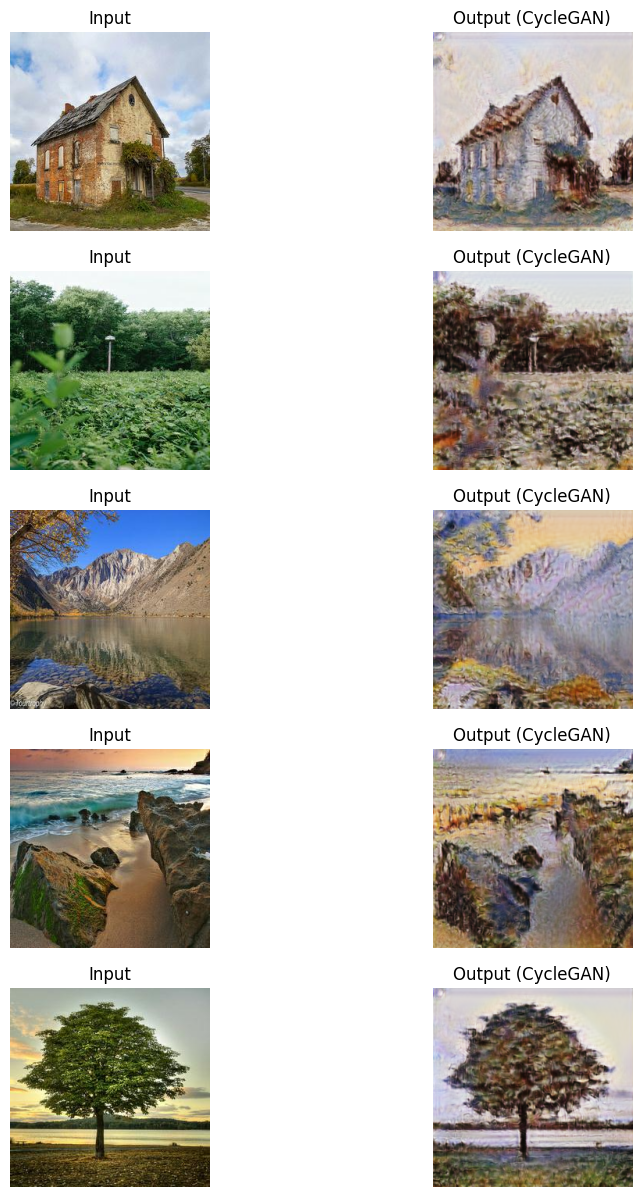

In [ ]:
# Cell 5: Evaluation & Visualization (Menggabungkan proses pemuatan data uji (Inference) dengan kode Matplotlib untuk menampilkan perbandingan gambar.)
G_AB.eval()
test_path = os.path.join(DATASET_PATH, 'testA')
test_files = sorted([f for f in os.listdir(test_path) if f.endswith(('.jpg', '.png'))])[:5]

plt.figure(figsize=(10, 15))
for i, f in enumerate(test_files):
    img = Image.open(os.path.join(test_path, f)).convert("RGB")
    input_tensor = transforms.Compose([transforms.Resize(256), transforms.ToTensor(), transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = G_AB(input_tensor).cpu().squeeze(0)

    output = (output * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()

    plt.subplot(5, 2, i*2+1); plt.imshow(img); plt.title("Input"); plt.axis('off')
    plt.subplot(5, 2, i*2+2); plt.imshow(output); plt.title("Output (CycleGAN)"); plt.axis('off')
plt.show()